In [2]:
dandiset_id = "000986"
dandi_path = "sub-LA11/sub-LA11_ses-2_behavior.nwb"
model_dir = f"/home/sambray/Documents/c3po/tutorial/c3po_models_{dandiset_id}"
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "7"  # Disable GPU usage for this example

from pathlib import Path
from dandi.dandiapi import DandiAPIClient
from dandi.consts import known_instances
import fsspec
from fsspec.implementations.cached import CachingFileSystem
import h5py
import pynwb

def get_dandi_file(dandiset_id, dandi_path, dandi_instance="dandi"):
    tmp_dir = "dandi_cache"  # Local folder for cache
    Path(tmp_dir).mkdir(exist_ok=True)  # Create the cache folder if it doesn't exist

    # get the s3 url from Dandi
    with DandiAPIClient(
        dandi_instance=known_instances[dandi_instance],
    ) as client:
        asset = client.get_dandiset(dandiset_id).get_asset_by_path(dandi_path)
        s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)

    # stream the file from s3
    # first, create a virtual filesystem based on the http protocol
    fs = fsspec.filesystem("http")

    # create a cache to save downloaded data to disk (optional)
    fsspec_file = CachingFileSystem(
        fs=fs,
        cache_storage=tmp_dir,  # Local folder for cache
    )

    # Open and return the file
    fs_file = fsspec_file.open(s3_url, "rb")
    io = pynwb.NWBHDF5IO(file=h5py.File(fs_file))
    nwbfile = io.read()
    return io, nwbfile

In [3]:
nwbfile = get_dandi_file(dandiset_id, dandi_path, dandi_instance="dandi")[1]

In [7]:
from c3po.analysis.analysis import C3poAnalysis
import numpy as np
analysis = C3poAnalysis(model_dir=model_dir)
analysis.fit_context_pca()
t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
analysis.interpolate_context(t_interp)
analysis.embed_context_pca()

In [13]:
trials = nwbfile.intervals['trials'].to_dataframe()

In [35]:
pupil_obj = nwbfile.processing['behavior']['PupilTracking']['pupil_diameter']
t_pupil = pupil_obj.timestamps[:]
pupil = pupil_obj.data[:]

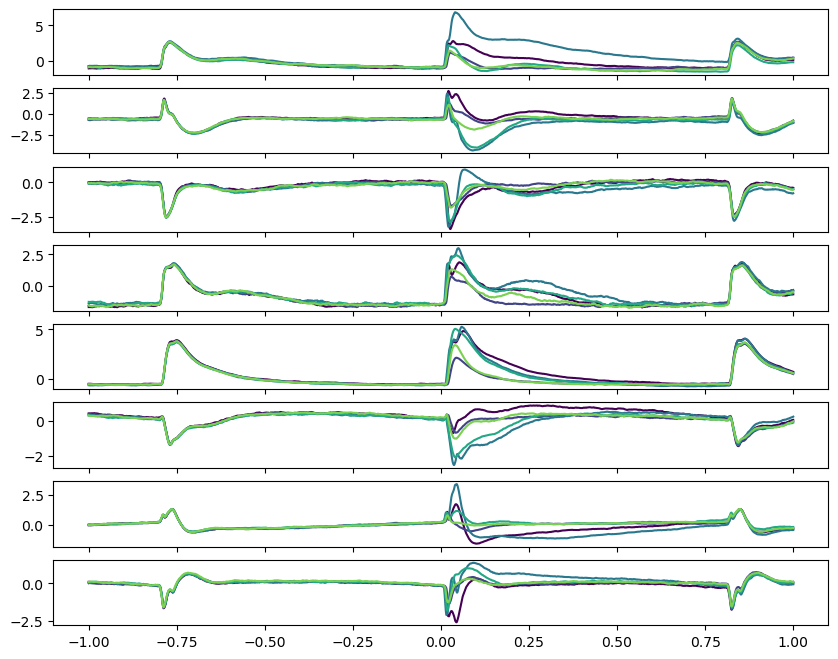

In [26]:
import matplotlib.pyplot as plt
freqs = np.sort(trials.stim_frequency.unique())
fig, ax = plt.subplots(nrows = 8, sharex=True, figsize=(10, 8))

mark = "start_time"
window = (-1,1)
for j,freq in enumerate(freqs):
    color = plt.cm.viridis(j/len(freqs))
    _df = trials[trials.stim_frequency==freq]
    mark_times = _df[mark].values
    result = analysis.alligned_response(mark_times, t_plot=window, pca=True)
    mid = np.mean(result, axis=0)
    t_plot = np.linspace(*window, mid.shape[0])
    for i, a in enumerate(ax):
        a.plot(t_plot,mid[:,i], color=color)
        # a.plot(mid[i,:], color="black")

In [ ]:
trials
pupil_trial = []
from tqdm import tqdm
ind_st = np.digitize(trials.start_time.values-.25, t_pupil)
ind_end = np.digitize(trials.stop_time.values+.25, t_pupil)
for i in tqdm(range(len(trials))):
    pupil_trial.append(np.nanmean(pupil[ind_st[i]:ind_end[i]]))
# for i, row in tqdm(trials.iterrows()):
#     start = row.start_time
#     end = row.stop_time
#     ind_st = np.digitize(start, t_pupil)
#     ind_end = np.digitize(end, t_pupil[ind_st:]) + ind_st
#     pupil_trial.append(np.mean(pupil[ind_st:ind_end]))
pupil_trial = np.array(pupil_trial)
pupil_trial = pupil_trial - np.nanmin(pupil_trial)
pupil_trial = pupil_trial / np.nanmax(pupil_trial)
trials['pupil'] = pupil_trial

  0%|          | 0/7448 [00:00<?, ?it/s]/tmp/ipykernel_2514704/1735963938.py:7: RuntimeWarning: Mean of empty slice
  pupil_trial.append(np.nanmean(pupil[ind_st[i]:ind_end[i]]))
100%|██████████| 7448/7448 [00:00<00:00, 34712.55it/s]


Text(0.5, 0, 'Time from Stimulus (s)')

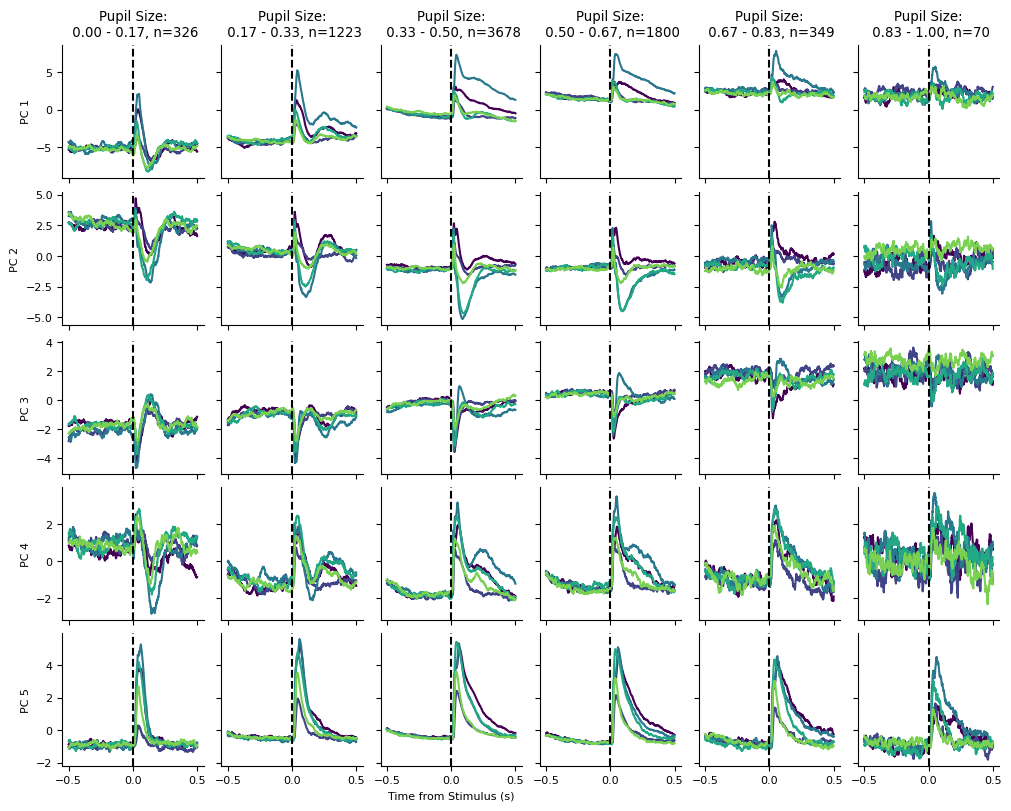

In [ ]:
pupil_ranges = np.linspace(0,1, 7)
window = (-.5,.5)
plt.rcParams['font.size'] = 8
n_pc = 5
ncols = pupil_ranges.size - 1
fig, ax = plt.subplots(nrows=n_pc, ncols=ncols, sharex=True, figsize=(10, 8),
                       sharey="row", constrained_layout=True)
for j in range(ncols):
    pupil_mask = (trials.pupil >= pupil_ranges[j]) & (trials.pupil < pupil_ranges[j+1])
    _df_pupil = trials[pupil_mask]
    ax[0,j].set_title(f"Pupil Size:\n {pupil_ranges[j]:.2f} - {pupil_ranges[j+1]:.2f}, n={len(_df_pupil)}")

    for k, freq in enumerate(freqs):
        color = plt.cm.viridis(k/len(freqs))
        _df = _df_pupil[_df_pupil.stim_frequency==freq]
        mark_times = _df[mark].values
        result = analysis.alligned_response(mark_times, t_plot=window, pca=True)
        mid = np.mean(result, axis=0)
        # r = np.nanpercentile(result, [25, 50, 75], axis=0)
        # mid = r[1]
        # low = r[0]
        # high = r[2]
        t_plot = np.linspace(*window, mid.shape[0])
        for i in range(n_pc):
            ax[i,j].plot(t_plot,mid[:,i], color=color)
            # ax[i,j].fill_between(t_plot, low[:,i], high[:,i], facecolor=color, alpha=0.2)

for a in ax.flatten():
    a.axvline(0, color="black", ls="--")
    a.spines[['top', 'right']].set_visible(False)

for i in range(n_pc):
    ax[i,0].set_ylabel(f"PC {i+1}")

ax[-1,2].set_xlabel("Time from Stimulus (s)")

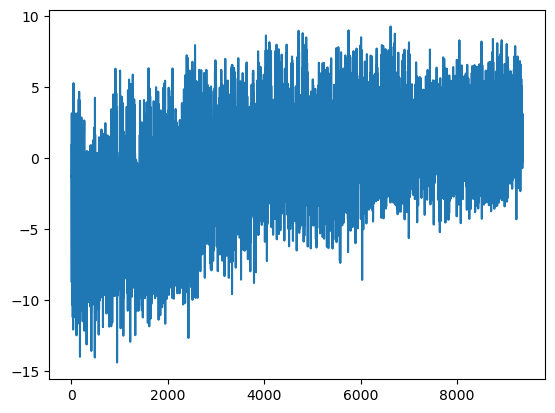

In [63]:
plt.plot(analysis.c_pca[::500,1],)

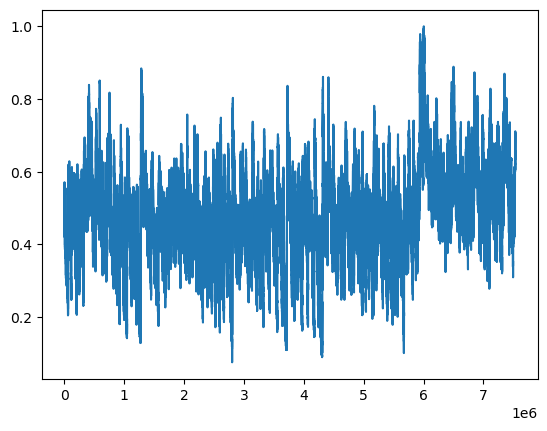

In [64]:
plt.plot(pupil)